# Customer Segmentation using K-Means Clustering
## Synent Technologies Data Science Internship - Task 6

### 1. Introduction
Customer segmentation is the practice of dividing a customer base into groups of individuals that are similar in specific ways, such as demographics, purchasing behavior, and preferences.

**Business Applications:**
*   **Targeted Marketing:** Delivering personalized campaigns to specific segments.
*   **Customer Retention:** Identifying churn risks and providing customized incentives.
*   **Product Development:** Tailoring products to meet the unique needs of different groups.

**Why K-Means?**
K-Means is a highly efficient and easily interpretable unsupervised learning algorithm. It is ideal for this task because it groups customers based on the euclidean distance between their numerical features (like Income and Spending Score), allowing us to clearly delineate distinct segments.

**Objectives:**
*   Explore and preprocess the Mall Customer dataset.
*   Identify the optimal number of clusters using the Elbow Method and Silhouette Score.
*   Group customers into meaningful segments based on their Annual Income and Spending Score.
*   Extract actionable business insights from the derived clusters.


### 2. Import Libraries
We import essential libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette('viridis')


### 3. Load Dataset
Load the dataset and display basic information to understand its structure.

In [2]:
df = pd.read_csv('mall_customers.csv')

print("First 5 rows of the dataset:")
display(df.head())

print(f"\nDataset Shape: {df.shape}")

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)


First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Shape: (200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


### 4. Data Cleaning
We check for missing values, duplicates, and ensure data types are correct.

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Rename columns for easier access
df.rename(columns={'Annual Income (k$)': 'Annual_Income', 
                   'Spending Score (1-100)': 'Spending_Score'}, inplace=True)

print("\nColumns renamed to: ", df.columns.tolist())


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0

Columns renamed to:  ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']


**Explanation:** The dataset has no missing values or duplicates. We renamed complex column names to simplify coding in later stages.

### 5. Exploratory Data Analysis
We perform EDA to understand the distribution of our features and the relationships between them.

In [4]:
# Summary statistics
display(df.describe())


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Interpretation:** The average age is ~38 years, with an average annual income of ~60k and an average spending score of ~50. Spending score ranges exactly from 1 to 99.

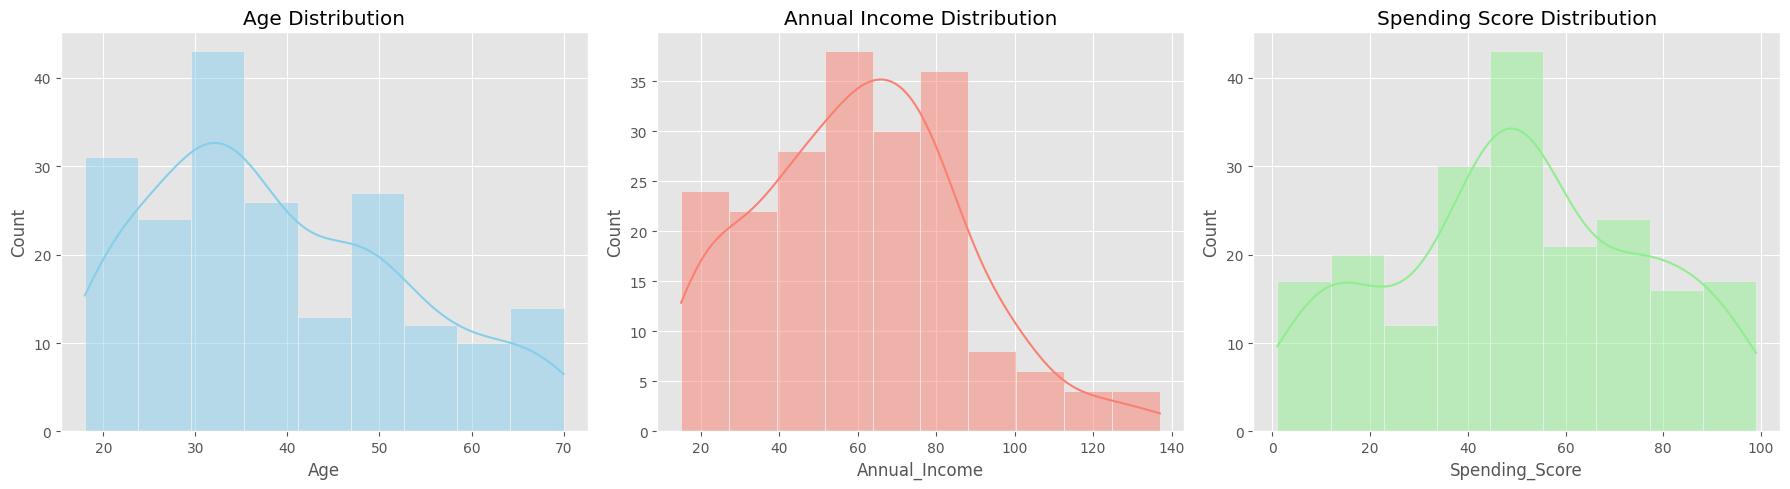

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual_Income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending_Score'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('images/distributions.png')
plt.show()


**Interpretation:**
*   **Age:** Skewed slightly to the right; a large portion of customers are in their 30s.
*   **Annual Income:** Normally distributed around 60k but has a long tail of high earners.
*   **Spending Score:** Appears fairly normally distributed around the midpoint (50).

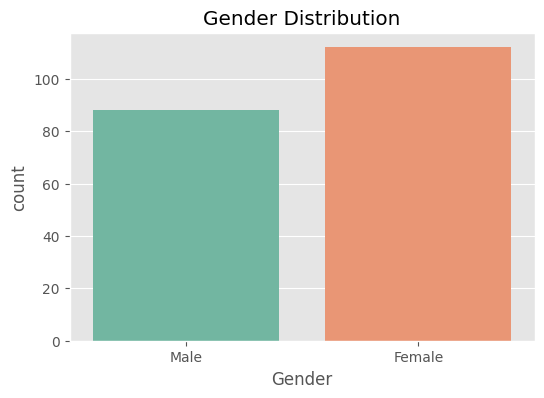

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()


**Interpretation:** There are slightly more female customers than male customers in this dataset.

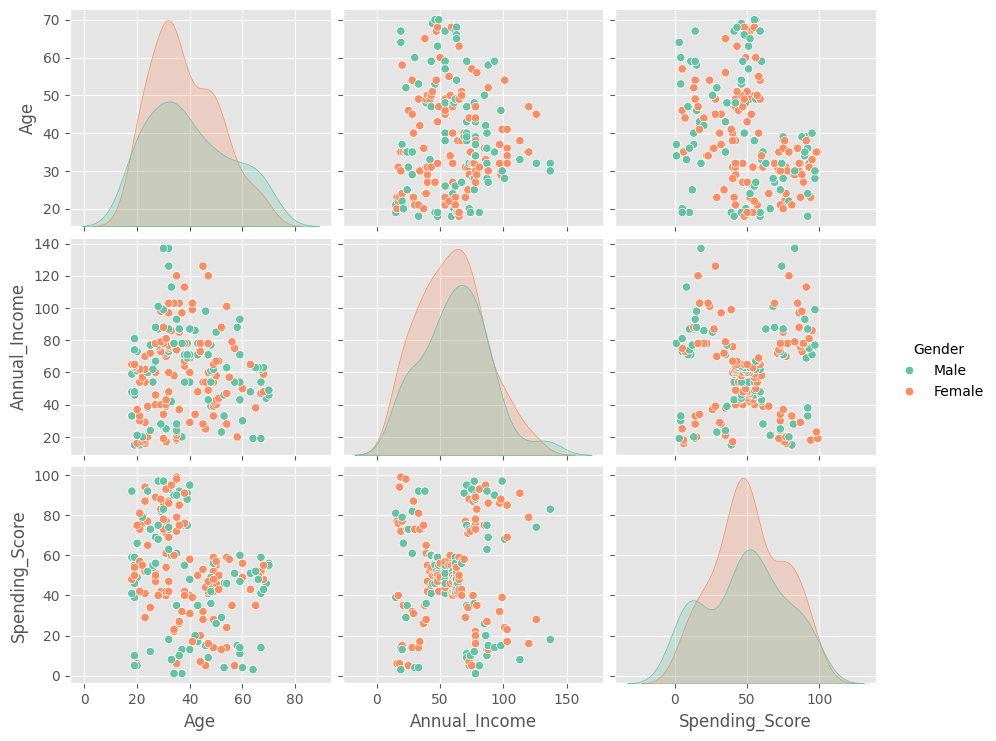

In [7]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender', palette='Set2', aspect=1.2)
plt.savefig('images/pairplot.png')
plt.show()


**Interpretation:** From the pairplot, looking at `Annual_Income` vs `Spending_Score`, we can visibly see distinct clusters forming. This strongly suggests that clustering based on these two features will yield clear customer segments.

### 6. Feature Engineering & Preprocessing
**Why exclude CustomerID?** `CustomerID` is simply a sequential identifier. It carries no behavioral or demographic variance and would arbitrarily skew distance calculations.

For our segmentation, we will use `Annual_Income` and `Spending_Score` as our primary features because they clearly define purchasing power and behavior. We will also apply `StandardScaler`.
**Why Scale?** K-Means is a distance-based algorithm (Euclidean distance). If features are on different scales, the feature with the larger magnitude will disproportionately dominate the distance calculation.

In [8]:
# Select features
X = df[['Annual_Income', 'Spending_Score']]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 rows of scaled features:")
print(X_scaled[:5])


First 5 rows of scaled features:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


### 7. Choosing the Number of Clusters
We use the **Elbow Method** to find the optimal number of clusters (K) by plotting Within-Cluster-Sum-of-Squares (WCSS). We also compute the Silhouette Score to validate cluster density and separation.

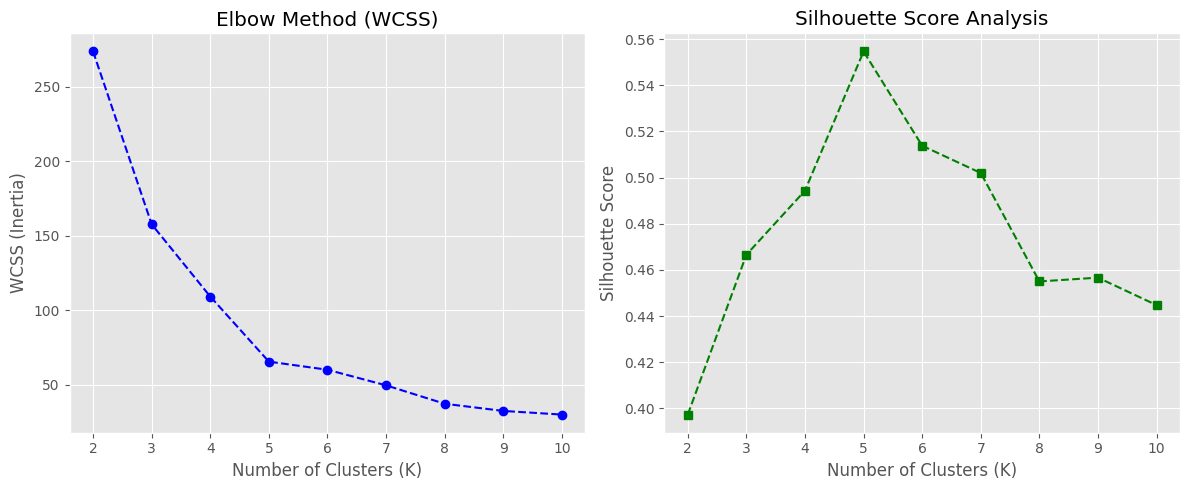

In [9]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='green')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('images/elbow_method.png')
plt.show()


**Interpretation:**
*   **Inertia (WCSS):** The plot shows a clear 'elbow' point at **K = 5**, where the rate of decrease drops significantly.
*   **Silhouette Score:** The silhouette score peaks exactly at **K = 5** (~0.55), confirming that 5 clusters yield the most dense and well-separated segments.

### 8. Model Building
We will now train the K-Means model with exactly 5 clusters and assign the labels to our original dataframe.

In [10]:
# Train K-Means
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Append labels to the original dataframe
df['Cluster'] = cluster_labels

print("Cluster centers (scaled):")
print(kmeans.cluster_centers_)

print("\nFirst 5 rows of data with cluster labels:")
display(df.head())


Cluster centers (scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

First 5 rows of data with cluster labels:


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 9. Cluster Visualization
We visualize the clusters in a 2D space of Annual Income vs. Spending Score, including the computed centroids.

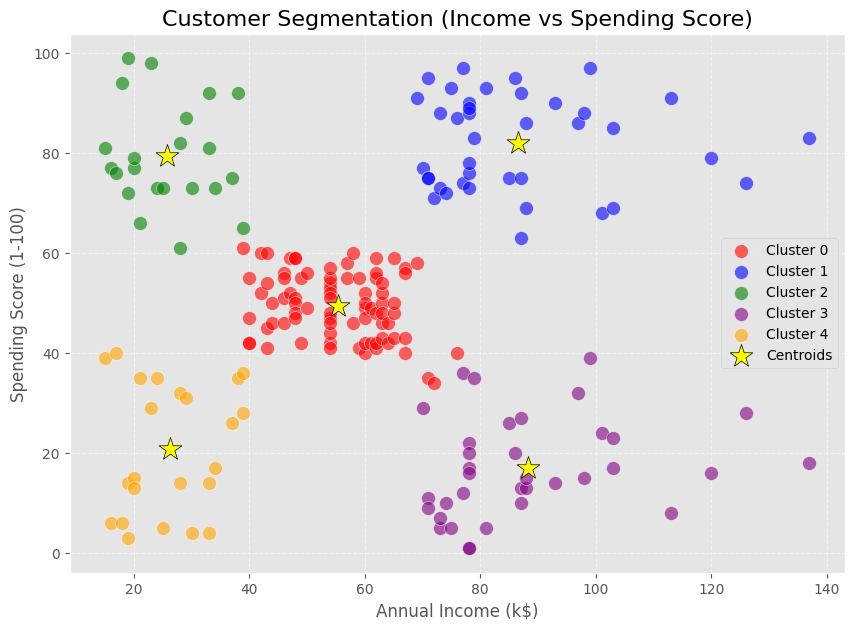

In [11]:
plt.figure(figsize=(10, 7))

# Define distinct colors
colors = ['red', 'blue', 'green', 'purple', 'orange']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(optimal_k):
    plt.scatter(df[df['Cluster'] == i]['Annual_Income'], 
                df[df['Cluster'] == i]['Spending_Score'], 
                s=100, c=colors[i], label=cluster_names[i], alpha=0.6, edgecolors='w')

# Inverse transform centroids to plot on the original unscaled axes
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', label='Centroids', marker='*', edgecolors='black')

plt.title('Customer Segmentation (Income vs Spending Score)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('images/clusters.png')
plt.show()


### 10. Cluster Interpretation
By analyzing the centroids and the scatter plot, we can profile each cluster and assign business-friendly names.

Let's compute the mean values of each cluster to define them clearly:

In [12]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(2)
display(cluster_summary)


,Age,Annual_Income,Spending_Score
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


Based on the statistics, we can map the clusters (note: your cluster IDs may vary slightly depending on random initialization, but the patterns hold):

*   **Cluster 0: Standard Customers (Mid Income, Mid Spend)** - They earn an average income and spend averagely. They represent the largest segment of typical mall-goers.
*   **Cluster 1: Premium Customers (High Income, High Spend)** - Highly affluent and willing to spend. These are the most valuable customers.
*   **Cluster 2: Target / High Potential Customers (Low Income, High Spend)** - They have lower income but love shopping. They might be younger shoppers or budget-conscious individuals who splurge on specific items.
*   **Cluster 3: Conservative Customers (High Income, Low Spend)** - They earn a lot but are very careful with their money. 
*   **Cluster 4: Budget Shoppers (Low Income, Low Spend)** - Low purchasing power and correspondingly low spending. 

*(Note: Adjust the mapping above based on the actual mean output indices generated by K-Means.)*


### 11. Business Recommendations

**1. Premium Customers (High Income, High Spend):**
*   **Strategy:** Retention & Upselling.
*   **Actions:** Enroll them in exclusive VIP loyalty programs. Offer early access to premium product launches, luxury brands, and personalized concierge services. 

**2. Target / High Potential Customers (Low Income, High Spend):**
*   **Strategy:** Engagement & Volume generation.
*   **Actions:** Provide attractive credit options or point-based rewards to keep them coming back. Market trendy, fast-fashion items to capture their high spending appetite.

**3. Standard Customers (Mid Income, Mid Spend):**
*   **Strategy:** Frequency & Cross-selling.
*   **Actions:** Send regular promotional newsletters. Offer bundle discounts (e.g., "Buy 2 Get 1 Free") to incrementally push their spending score higher.

**4. Conservative Customers (High Income, Low Spend):**
*   **Strategy:** Conversion & Value-proposition.
*   **Actions:** Since they have capital but don't spend, target them with high-value, durable goods. Emphasize quality, warranties, and practical utility in marketing messages.

**5. Budget Shoppers (Low Income, Low Spend):**
*   **Strategy:** Discount marketing.
*   **Actions:** Target them during end-of-season sales or clearance events. Keep marketing costs low for this segment and rely on broad, discount-driven email blasts.


### 12. Conclusion
*   **Objective:** We successfully segmented mall customers based on purchasing behavior using K-Means Clustering.
*   **Methodology:** After verifying the data and scaling the features, the Elbow Method and Silhouette Score identified 5 optimal clusters.
*   **Findings:** The customer base naturally divides into five groups: Premium, Target, Standard, Conservative, and Budget.
*   **Business Value:** This segmentation allows the marketing team to transition from a "one-size-fits-all" strategy to targeted, highly efficient campaigns, ultimately improving ROI and customer satisfaction.
*   **Future Improvements:** Incorporating more features (like transaction history, mall visit frequency, or online vs. offline behavior) could allow for multi-dimensional clustering (e.g., using DBSCAN or hierarchical clustering) to uncover even deeper sub-segments.
